# Photoelectric Effect Analysis

This notebook analyzes photoelectric effect experimental data to determine:
- Stopping potential (V₀) for different light frequencies
- Planck's constant (h)
- Work function (φ) of the photocathode material

In [1]:
# =============================================================================
# IMPORTS
# =============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.signal import savgol_filter
from scipy.optimize import curve_fit

In [2]:
# =============================================================================
# CONFIGURATION
# =============================================================================

# Data directory
DATA_DIR = (
    r"C:\Users\gabri\Documents\PROJETOS\POLI\PY\Lab Física\Fotoelétrico\attachments"
)

# Physical constants
H_PLANCK = 4.135667696e-15  # eV.s (Planck's constant)
C_LIGHT = 299792458  # m/s (Speed of light)

# Experimental parameters
SIGMA_INSTRUMENTAL = 0.005  # Instrumental uncertainty (V)
SCALE_FACTOR = 1e10  # Scale factor for current (improves numerical stability)

# Light frequencies (× 10^14 Hz)
FREQUENCIES = {
    "Vermelho": 4.875,
    "Amarelo": 5.187,
    "Verde": 5.490,
    "Azul": 6.879,
    "Violeta": 7.409,
    "Ultra-Violeta": 8.213,
}

# Expected V0 values for validation (V)
EXPECTED_V0 = {
    "Ultra-Violeta": 2.03,
    "Violeta": 1.70,
    "Azul": 1.48,
    "Verde": 0.91,
    "Amarelo": 0.78,
    "Vermelho": 0.65,
}

# Color configurations for data files
COLORS_CONFIG = [
    {"name": "Vermelho", "prefix": "ver"},
    {"name": "Amarelo", "prefix": "amar"},
    {"name": "Verde", "prefix": "verde"},
    {"name": "Azul", "prefix": "azul"},
    {"name": "Violeta", "prefix": "vio"},
    {"name": "Ultra-Violeta", "prefix": "UV"},
]

# Intensity levels (%)
INTENSITIES = [100, 80, 60, 40, 20]

# Plot style
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.size": 12,
        "axes.axisbelow": True,
    }
)

In [3]:
# =============================================================================
# DATA LOADING
# =============================================================================


def load_background_data():
    """Load background noise data for correction."""
    sem_file = os.path.join(DATA_DIR, "sem.csv")
    return pd.read_csv(sem_file, sep=";", decimal=",")


def load_color_data(prefix: str, intensity: int, background_df: pd.DataFrame = None):
    """
    Load I-V curve data for a specific color and intensity.

    Args:
        prefix: File prefix for the color (e.g., 'ver', 'azul')
        intensity: Light intensity percentage
        background_df: Optional background data for noise correction

    Returns:
        Tuple of (voltage, current) arrays, or None if file doesn't exist
    """
    filepath = os.path.join(DATA_DIR, f"{prefix}-{intensity}.csv")

    if not os.path.exists(filepath):
        return None

    df = pd.read_csv(filepath, sep=";", decimal=",")
    voltage = df["Tensao [V]"].values
    current = df["Corrente [A]"].values

    # Apply background correction if available
    if background_df is not None and len(current) == len(background_df):
        current = current - background_df["Corrente [A]"].values

    return voltage, current


# Load background data
df_background = load_background_data()
print(f"Background data loaded: {len(df_background)} points")

Background data loaded: 401 points


In [4]:
# =============================================================================
# V0 DETERMINATION - STATISTICAL ONSET METHOD
# =============================================================================


def calculate_v0_statistical_onset(
    voltage: np.ndarray,
    current: np.ndarray,
    noise_region: tuple = (-9, -3),
    confidence_sigma: float = 3.0,
    min_noise_points: int = 10,
) -> float:
    """
    Determine stopping potential (V0) using 2nd derivative statistical onset method.

    Analyzes the second derivative of the I-V curve to detect when the signal
    exits the noise band, indicating the onset of photocurrent.

    Args:
        voltage: Voltage array
        current: Current array
        noise_region: Voltage range to characterize baseline noise (V_min, V_max)
        confidence_sigma: Number of standard deviations for threshold
        min_noise_points: Minimum points required in noise region

    Returns:
        V0 value, or NaN if determination fails
    """
    if len(voltage) < 50:
        return np.nan

    # Determine Savitzky-Golay window size (must be odd)
    window_size = min(21, len(current) // 5)
    if window_size < 5:
        return np.nan
    window_size = window_size if window_size % 2 == 1 else window_size + 1

    # Scale current and compute smoothed 2nd derivative
    scaled_current = current * SCALE_FACTOR
    smoothed = savgol_filter(scaled_current, window_size, 3)
    first_deriv = np.gradient(smoothed, voltage)
    second_deriv = np.gradient(first_deriv, voltage)

    # Extract noise region data
    noise_mask = (voltage >= noise_region[0]) & (voltage <= noise_region[1])
    if np.sum(noise_mask) < min_noise_points:
        return np.nan

    v_noise = voltage[noise_mask]
    d2i_noise = second_deriv[noise_mask]

    try:
        # Linear regression on noise region
        reg = stats.linregress(v_noise, d2i_noise)
        predicted = reg.intercept + reg.slope * v_noise
        residuals = d2i_noise - predicted

        # Remove outliers using IQR method
        q1, q3 = np.percentile(residuals, [25, 75])
        iqr = q3 - q1
        clean_mask = (residuals >= q1 - 1.5 * iqr) & (residuals <= q3 + 1.5 * iqr)

        if np.sum(clean_mask) < min_noise_points // 2:
            return np.nan

        noise_std = np.std(residuals[clean_mask])

        # Search for point that exits the noise band
        search_indices = np.where(voltage > noise_region[1])[0]
        for idx in search_indices:
            predicted_val = reg.intercept + reg.slope * voltage[idx]
            actual_val = second_deriv[idx]

            if np.abs(actual_val - predicted_val) > confidence_sigma * noise_std:
                return voltage[idx]

    except Exception:
        return np.nan

    return np.nan

In [5]:
# =============================================================================
# VISUALIZATION - STACKED ANALYSIS PLOT
# =============================================================================


def plot_stacked_analysis(
    curves: list,
    color_name: str,
    noise_region: tuple = (-9, -3),
    sigma_mult: float = 3.0,
):
    """
    Generate stacked visualization of 2nd derivative analysis for V0 determination.

    Args:
        curves: List of (voltage, current, label) tuples
        color_name: Name of the light color being analyzed
        noise_region: Voltage range for noise characterization
        sigma_mult: Sigma multiplier for confidence bands
    """
    n_curves = len(curves)
    fig, axes = plt.subplots(n_curves, 1, figsize=(6, 2 * n_curves), sharex=True)
    if n_curves == 1:
        axes = [axes]
    plt.subplots_adjust(hspace=0, left=0.15, right=0.95, top=0.92, bottom=0.1)

    # Calculate mean V0 across all curves
    v0_values = [
        calculate_v0_statistical_onset(v, i, noise_region, sigma_mult)
        for v, i, _ in curves
    ]
    valid_v0 = [v for v in v0_values if not np.isnan(v)]
    mean_v0 = np.mean(valid_v0) if valid_v0 else np.nan

    for idx, (ax, (voltage, current, label)) in enumerate(zip(axes, curves)):
        # Compute 2nd derivative
        window = max(15, min(21, len(current) // 5)) | 1
        scaled = current * SCALE_FACTOR
        smoothed = savgol_filter(scaled, window, 3)
        second_deriv = np.gradient(np.gradient(smoothed, voltage), voltage)

        # Plot 2nd derivative
        ax.plot(
            voltage,
            second_deriv,
            color="navy",
            lw=1.2,
            label=f'2nd derivative "{label}"',
        )

        # Add noise band visualization
        noise_mask = (voltage >= noise_region[0]) & (voltage <= noise_region[1])
        if np.sum(noise_mask) > 5:
            reg = stats.linregress(voltage[noise_mask], second_deriv[noise_mask])
            x_range = np.array([voltage.min(), voltage.max()])
            y_trend = reg.intercept + reg.slope * x_range

            residuals = second_deriv[noise_mask] - (
                reg.intercept + reg.slope * voltage[noise_mask]
            )
            pred_interval = sigma_mult * np.std(residuals)
            conf_interval = pred_interval * 0.3

            # Confidence and prediction bands
            ax.fill_between(
                x_range,
                y_trend - conf_interval,
                y_trend + conf_interval,
                color="#808080",
                alpha=0.6,
                label="68% Confidence Band",
            )
            ax.fill_between(
                x_range,
                y_trend - pred_interval,
                y_trend + pred_interval,
                color="#D3D3D3",
                alpha=0.5,
                label="68% Prediction Band",
            )
            ax.plot(x_range, y_trend, "k-", lw=1.5, label="Linear Fit")

        # Formatting
        ax.tick_params(axis="both", direction="in", top=True, right=True, labelsize=10)
        ax.legend(
            loc="upper left",
            fontsize=7,
            frameon=True,
            fancybox=False,
            edgecolor="black",
            framealpha=1.0,
        )
        ax.set_xlim(-10, 1)

        # Adjust Y limits
        mask_view = (voltage >= -10) & (voltage <= 1)
        if np.any(mask_view):
            y_vis = second_deriv[mask_view]
            margin = (y_vis.max() - y_vis.min()) * 0.1
            ax.set_ylim(y_vis.min() - margin, y_vis.max() + margin)

        if idx < n_curves - 1:
            ax.set_xticklabels([])

    # Draw V0 line across all subplots
    if not np.isnan(mean_v0):
        for ax in axes:
            ax.axvline(mean_v0, color="red", ls="-", lw=2, zorder=10)
        axes[0].text(
            mean_v0,
            1.02,
            f"{abs(mean_v0):.2f}",
            transform=axes[0].get_xaxis_transform(),
            ha="center",
            va="bottom",
            fontsize=14,
            fontstyle="italic",
            family="serif",
        )

    fig.text(
        0.5,
        0.02,
        "Tensão Aplicada (V)",
        ha="center",
        fontsize=14,
        fontstyle="italic",
        family="serif",
    )
    plt.show()

Processing data and calculating V0...

--- Visual Analysis: Ultra-Violeta ---


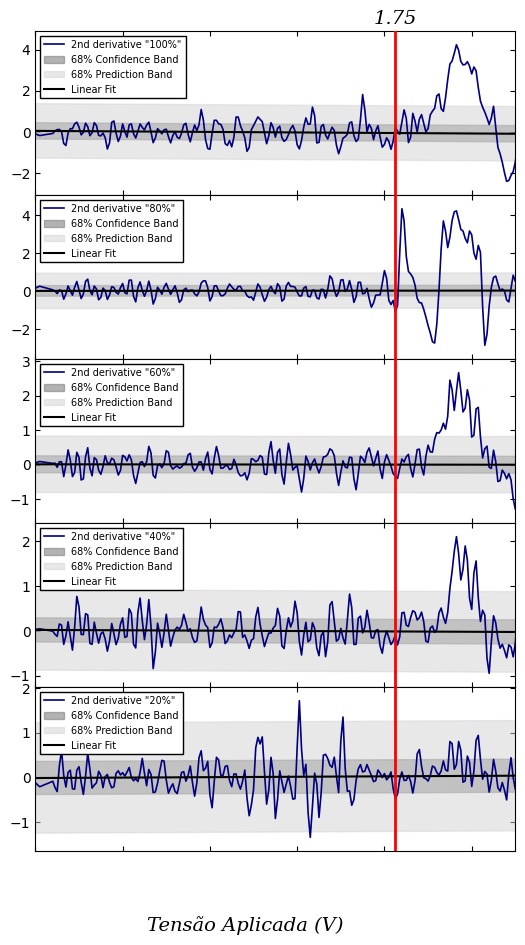


=== V0 Determination Results (Volts) ===


,Frequencia,V0,Sigma_V0,Esperado,Erro_%
Cor,,,,,
Vermelho,4.8750,1.1600,0.1914,0.6500,78.46%
Amarelo,5.1870,1.2500,0.1754,0.7800,60.26%
Verde,5.4900,1.3300,0.3020,0.9100,46.15%
Azul,6.8790,1.7200,0.2108,1.4800,16.22%
Violeta,7.4090,1.7600,0.0433,1.7000,3.53%
Ultra-Violeta,8.2130,1.7500,0.4759,2.0300,-13.79%


In [6]:
# =============================================================================
# MAIN ANALYSIS - PROCESS ALL COLORS
# =============================================================================


def process_all_colors(
    background_df: pd.DataFrame, show_uv_plot: bool = True
) -> pd.DataFrame:
    """
    Process I-V curves for all colors and calculate V0 values.

    Args:
        background_df: Background noise data for correction
        show_uv_plot: Whether to show detailed plot for UV data

    Returns:
        DataFrame with V0 results for each color
    """
    results = []

    for config in COLORS_CONFIG:
        color_name = config["name"]
        prefix = config["prefix"]

        # Load all intensity curves for this color
        curves = []
        curves_labeled = []

        for intensity in INTENSITIES:
            data = load_color_data(prefix, intensity, background_df)
            if data is None:
                continue
            voltage, current = data
            curves.append((voltage, current))
            curves_labeled.append((voltage, current, f"{intensity}%"))

        if not curves:
            continue

        # Calculate V0 for each intensity
        v0_values = [calculate_v0_statistical_onset(v, i) for v, i in curves]
        v0_valid = [abs(x) for x in v0_values if not np.isnan(x)]

        if not v0_valid:
            continue

        # Statistics
        v0_mean = np.mean(v0_valid)
        sigma_statistical = (
            np.std(v0_valid, ddof=1) / np.sqrt(len(v0_valid))
            if len(v0_valid) > 1
            else 0.0
        )
        sigma_total = np.sqrt(sigma_statistical**2 + SIGMA_INSTRUMENTAL**2)

        # Compare with expected value
        expected = EXPECTED_V0.get(color_name, np.nan)
        error_pct = (
            100 * (v0_mean - expected) / expected if not np.isnan(expected) else np.nan
        )

        results.append(
            {
                "Cor": color_name,
                "Frequencia": FREQUENCIES.get(color_name, np.nan),
                "V0": v0_mean,
                "Sigma_V0": sigma_total,
                "Esperado": expected,
                "Erro_%": error_pct,
            }
        )

        # Show detailed plot for UV
        if color_name == "Ultra-Violeta" and show_uv_plot:
            print(f"\n--- Visual Analysis: {color_name} ---")
            plot_stacked_analysis(curves_labeled, color_name)

    return pd.DataFrame(results).set_index("Cor")


# Run analysis
print("Processing data and calculating V0...")
df_results = process_all_colors(df_background)

# Display results
print("\n=== V0 Determination Results (Volts) ===")
display_cols = ["Frequencia", "V0", "Sigma_V0", "Esperado", "Erro_%"]
try:
    display(
        df_results[display_cols]
        .style.format("{:.4f}", subset=["Frequencia", "V0", "Sigma_V0", "Esperado"])
        .format("{:.2f}%", subset=["Erro_%"])
    )
except NameError:
    print(df_results[display_cols])

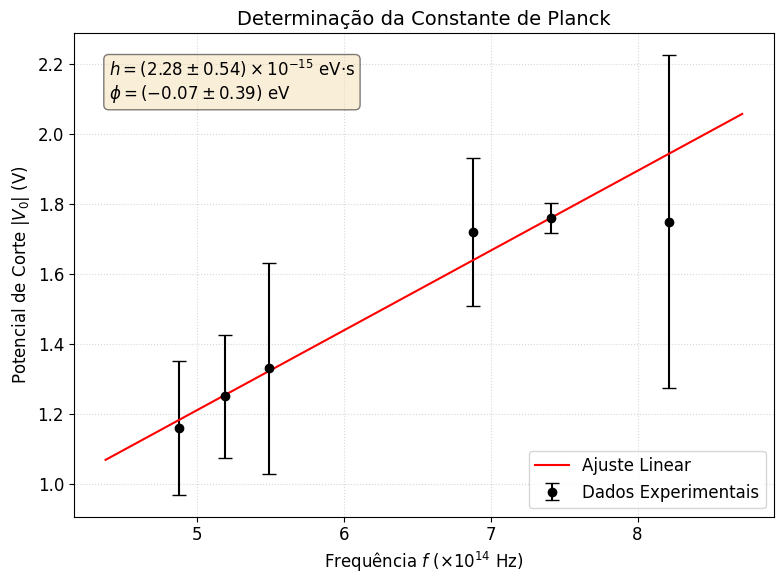

PLANCK'S CONSTANT (h)
  Measured: 2.2819e-15 ± 5.4e-16 eV·s
  Expected: 4.1357e-15 eV·s
  Relative Error: 44.82%
--------------------------------------------------
WORK FUNCTION (φ)
  Measured: -0.070 ± 0.390 eV


In [7]:
# =============================================================================
# PLANCK CONSTANT DETERMINATION
# =============================================================================


def calculate_planck_constant(df_results: pd.DataFrame) -> tuple:
    """
    Determine Planck's constant from V0 vs frequency linear fit.

    Uses weighted linear regression: V0 = (h/e) * f - φ

    Args:
        df_results: DataFrame with V0 results indexed by color name

    Returns:
        Tuple of (h_measured, h_error, work_function, work_function_error)
    """
    # Collect data in frequency order
    colors_ordered = [
        "Vermelho",
        "Amarelo",
        "Verde",
        "Azul",
        "Violeta",
        "Ultra-Violeta",
    ]

    freq_data, v0_data, sigma_data = [], [], []

    for color in colors_ordered:
        if color not in df_results.index:
            continue

        v0 = df_results.loc[color, "V0"]
        sigma = df_results.loc[color, "Sigma_V0"]

        if np.isnan(v0):
            continue

        freq_data.append(FREQUENCIES[color])
        v0_data.append(v0)
        sigma_data.append(sigma if not np.isnan(sigma) else 0.05)

    x = np.array(freq_data)
    y = np.array(v0_data)
    sigma = np.array(sigma_data)

    # Weighted linear regression
    def linear_model(x, slope, intercept):
        return slope * x + intercept

    popt, pcov = curve_fit(linear_model, x, y, sigma=sigma, absolute_sigma=True)
    slope, intercept = popt
    slope_err, intercept_err = np.sqrt(np.diag(pcov))

    # Physical constants extraction
    # V0 = (h/e)*f - φ, where f is in units of 10^14 Hz
    h_measured = slope * 1e-14  # eV.s
    h_error = slope_err * 1e-14
    work_function = -intercept  # eV (intercept is -φ)
    work_function_err = intercept_err

    return h_measured, h_error, work_function, work_function_err, x, y, sigma


def plot_planck_determination(df_results: pd.DataFrame):
    """
    Create plot for Planck constant determination with results.

    Args:
        df_results: DataFrame with V0 results
    """
    h_meas, h_err, phi_meas, phi_err, x, y, sigma = calculate_planck_constant(
        df_results
    )

    # Create figure
    fig, ax = plt.subplots(figsize=(8, 6))

    # Data points with error bars
    ax.errorbar(x, y, yerr=sigma, fmt="ko", capsize=5, label="Dados Experimentais")

    # Fit line
    x_range = np.linspace(min(x) - 0.5, max(x) + 0.5, 100)
    slope = h_meas * 1e14  # Convert back for plotting
    intercept = -phi_meas
    ax.plot(x_range, slope * x_range + intercept, "r-", label="Ajuste Linear")

    # Results text box
    textstr = "\n".join(
        [
            rf"$h = ({h_meas*1e15:.2f} \pm {h_err*1e15:.2f}) \times 10^{{-15}}$ eV·s",
            rf"$\phi = ({phi_meas:.2f} \pm {phi_err:.2f})$ eV",
        ]
    )
    props = dict(boxstyle="round", facecolor="wheat", alpha=0.5)
    ax.text(
        0.05,
        0.95,
        textstr,
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment="top",
        bbox=props,
    )

    # Labels and formatting
    ax.set_xlabel(r"Frequência $f$ ($\times 10^{14}$ Hz)", fontsize=12)
    ax.set_ylabel(r"Potencial de Corte $|V_0|$ (V)", fontsize=12)
    ax.set_title("Determinação da Constante de Planck", fontsize=14)
    ax.legend(loc="lower right")
    ax.grid(True, ls=":", alpha=0.5)

    plt.tight_layout()
    plt.show()

    # Print results
    print("=" * 50)
    print("PLANCK'S CONSTANT (h)")
    print(f"  Measured: {h_meas:.4e} ± {h_err:.1e} eV·s")
    print(f"  Expected: {H_PLANCK:.4e} eV·s")
    print(f"  Relative Error: {100*abs(h_meas - H_PLANCK)/H_PLANCK:.2f}%")
    print("-" * 50)
    print("WORK FUNCTION (φ)")
    print(f"  Measured: {phi_meas:.3f} ± {phi_err:.3f} eV")
    print("=" * 50)

    return h_meas, h_err, phi_meas, phi_err


# Run Planck constant determination
h_result, h_error, phi_result, phi_error = plot_planck_determination(df_results)